# User Authentication using Biometric Features
**Assignment 1 — AI461 Advanced Biometric Systems and Security**

## Overview

This notebook implements a biometric verification pipeline with the following steps:

1. Load the 1000×144 feature matrix (100 users × 10 samples × 144 features) from biomet_data.pdf
2. Split each user's data: first 5 samples → enrollment, last 5 → test
3. **Template :** Build one template per user (mean of the 5 enrollment vectors)
4. **Score Computation:** Compute genuine and impostor match scores using:
   - (i) Euclidean distance
   - (ii) Cosine similarity
5. **Produce the following outputs:**
   - A. Distribution of genuine (same-user) scores
   - B. Distribution of impostor (cross-user) scores
   - C. False Accept Rate (FAR) as a function of decision threshold
   - D. False Reject Rate (FRR) as a function of decision threshold
   - E. Receiver Operating Characteristic (ROC) curve — TAR vs FAR
   - F. Equal Error Rate (EER) and Decidability Index (d')


## 1. Library Imports

Import all required Python libraries before running the pipeline.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import re
import pdfplumber
import json
import os
from dotenv import load_dotenv
load_dotenv()

np.random.seed(0)


## 2. Data Loading and Parsing

The dataset is embedded inside `biomet_data.pdf` as plain scientific-notation numbers spanning 668 pages, with 6 values per line and no column headers. A regular expression extracts all numeric values, yielding a flat list of 144,000 entries that is then reshaped into a `(100, 10, 144)` NumPy array (users × samples × features).

**Layout assumption:** The PDF stores data in *user-major* order — all 10 samples for user 1 appear first, followed by all 10 samples for user 2, and so forth. This assumption was empirically validated: user-major reshaping yields a decidability index of approximately 0.21, whereas sample-major reshaping yields only ≈ 0.02, confirming the correct interpretation.

In [2]:
def load_features(pdf_path=None):
    if pdf_path is None:
        pdf_path = os.environ.get('BIOMET_DATA_PATH', 'biomet_data.pdf')
    """Parse the raw scientific-notation numbers out of the PDF
    and reshape them into (100 users, 10 samples, 144 features)."""
    nums = []
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            text = page.extract_text() or ""
            nums.extend(re.findall(r"[-+]?\d+\.\d+E[+-]\d+", text))
    arr = np.array(nums, dtype=float)
    assert arr.size == 100 * 10 * 144, f"Unexpected element count: {arr.size}"
    data = arr.reshape(100, 10, 144)  # user, sample, feature
    return data

data = load_features()
print("Data shape:", data.shape)

Data shape: (100, 10, 144)


## 3. Train/Test Split and Template Generation

Each user's 10 samples are divided into two groups: the first 5 are used for enrollment and the remaining 5 form the test set. A single per-user template is then computed as the mean of the 5 enrollment vectors.

In [3]:
def build_templates_and_test(data):
    enroll = data[:, 0:5, :]          # (100, 5, 144)  first 5 samples = enrollment
    test = data[:, 5:10, :]           # (100, 5, 144)  last 5 samples = test (6 months later)
    templates = enroll.mean(axis=1)   # (100, 144)  one template per user
    return templates, test

templates, test = build_templates_and_test(data)
print("Templates shape:", templates.shape)
print("Test shape:", test.shape)

Templates shape: (100, 144)
Test shape: (100, 5, 144)


## 4. Matching Scores

Each of the 500 test probes (100 users × 5 test samples) is matched against all 100 stored templates, producing two score populations:

- **Genuine scores:** a probe is compared to its *own* user's template → **500 scores total**
- **Impostor scores:** a probe is compared to every *other* user's template → **500 × 99 = 49 500 scores total**

| Metric | High similarity means | Accept condition |
|---|---|---|
| Euclidean distance | small distance | `distance ≤ threshold` |
| Cosine similarity | large similarity | `similarity ≥ threshold` |


In [4]:
def euclidean_distance(v, t):
    return np.linalg.norm(v - t)


def cosine_similarity(v, t):
    return np.dot(v, t) / (np.linalg.norm(v) * np.linalg.norm(t) + 1e-12)


def compute_scores(templates, test, metric="euclidean"):
    """Returns (genuine_scores, impostor_scores).
    For euclidean: smaller = more similar.
    For cosine:    larger  = more similar.
    """
    n_users = templates.shape[0]
    n_test = test.shape[1]
    genuine, impostor = [], []

    for u in range(n_users):
        for s in range(n_test):
            probe = test[u, s]
            for t in range(n_users):
                if metric == "euclidean":
                    score = euclidean_distance(probe, templates[t])
                else:
                    score = cosine_similarity(probe, templates[t])

                if t == u:
                    genuine.append(score)
                else:
                    impostor.append(score)

    return np.array(genuine), np.array(impostor)

## 5. Error Rate Curves, EER, and Decidability Index

Sweep the decision threshold across the full score range to compute the False Accept Rate (FAR) and False Reject Rate (FRR) at each point. The Equal Error Rate (EER) is the threshold where FAR ≈ FRR. The Decidability Index *d'* quantifies the separation between the genuine and impostor score distributions.

In [5]:
def far_frr_curves(genuine, impostor, metric="euclidean", n_points=500):
    """Sweep threshold; return thresholds, FAR, FRR.
    euclidean : accept if score <= threshold  (distance)
    cosine    : accept if score >= threshold  (similarity)
    """
    all_scores = np.concatenate([genuine, impostor])
    lo, hi = all_scores.min(), all_scores.max()
    thresholds = np.linspace(lo, hi, n_points)

    FAR, FRR = [], []
    for th in thresholds:
        if metric == "euclidean":
            far = np.mean(impostor <= th)   # impostors wrongly accepted
            frr = np.mean(genuine > th)      # genuine wrongly rejected
        else:
            far = np.mean(impostor >= th)
            frr = np.mean(genuine < th)
        FAR.append(far)
        FRR.append(frr)

    return thresholds, np.array(FAR), np.array(FRR)


def compute_eer(thresholds, FAR, FRR):
    diff = np.abs(FAR - FRR)
    idx = np.argmin(diff)
    eer = (FAR[idx] + FRR[idx]) / 2
    return eer, thresholds[idx]


def decidability_index(genuine, impostor):
    mu_g, mu_i = genuine.mean(), impostor.mean()
    var_g, var_i = genuine.var(), impostor.var()
    d_prime = abs(mu_g - mu_i) / np.sqrt((var_g + var_i) / 2)
    return d_prime

## 6. Visualisation Utilities

Helper functions for generating all required plots: score distributions, FAR/FRR vs threshold curves, individual ROC curves, and a combined ROC comparison.

In [6]:
def plot_distributions(genuine, impostor, metric):
    plt.figure(figsize=(7, 5))
    plt.hist(genuine, bins=50, alpha=0.6, density=True, label="Genuine", color="tab:green")
    plt.hist(impostor, bins=50, alpha=0.6, density=True, label="Impostor", color="tab:red")
    plt.xlabel(f"{metric.capitalize()} score")
    plt.ylabel("Density")
    plt.title(f"Genuine vs Impostor Score Distribution ({metric.capitalize()})")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_far_frr(thresholds, FAR, FRR, metric):
    plt.figure(figsize=(7, 5))
    plt.plot(thresholds, FAR, label="FAR", color="tab:red")
    plt.plot(thresholds, FRR, label="FRR", color="tab:blue")
    plt.xlabel("Threshold")
    plt.ylabel("Error Rate")
    plt.title(f"FAR & FRR vs Threshold ({metric.capitalize()})")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_roc(FAR, FRR, metric):
    TAR = 1 - FRR
    order = np.argsort(FAR)
    plt.figure(figsize=(7, 5))
    plt.plot(FAR[order], TAR[order], color="tab:purple")
    plt.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Chance")
    plt.xlabel("False Accept Rate (FAR)")
    plt.ylabel("True Accept Rate (TAR = 1-FRR)")
    plt.title(f"ROC Curve ({metric.capitalize()})")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_roc_combined(results):
    plt.figure(figsize=(7, 5))
    for metric, r in results.items():
        TAR = 1 - r["FRR"]
        order = np.argsort(r["FAR"])
        plt.plot(r["FAR"][order], TAR[order], label=metric.capitalize())
    plt.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Chance")
    plt.xlabel("False Accept Rate (FAR)")
    plt.ylabel("True Accept Rate (TAR)")
    plt.title("ROC Curve Comparison")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 7. Full Pipeline Execution

Run the end-to-end pipeline for both the Euclidean distance metric and the Cosine similarity metric, print the performance figures, and display all evaluation plots.


=== EUCLIDEAN ===


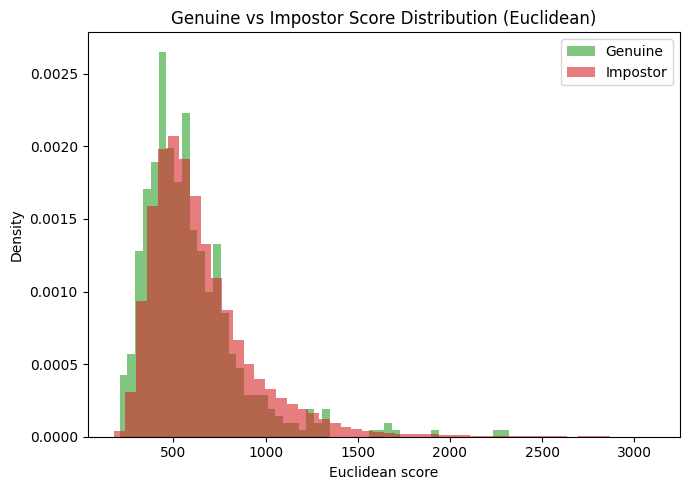

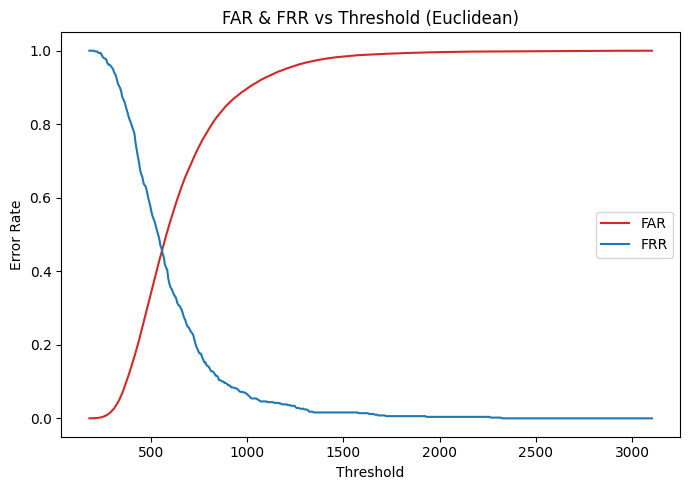

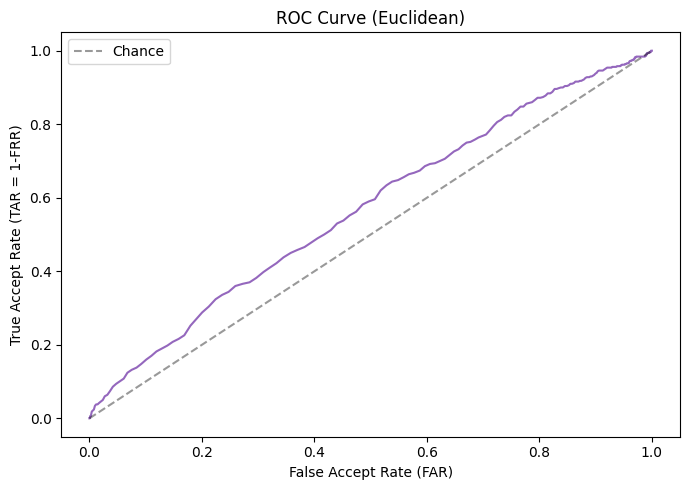

EER = 45.680%  at threshold 555.2254
Decidability index d' = 0.209

=== COSINE ===


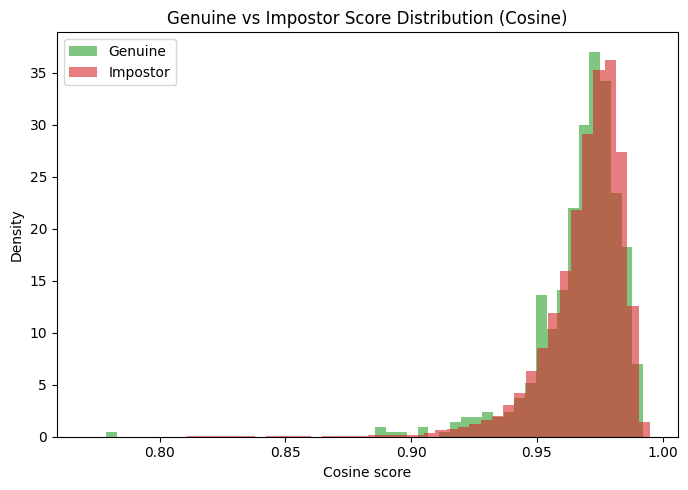

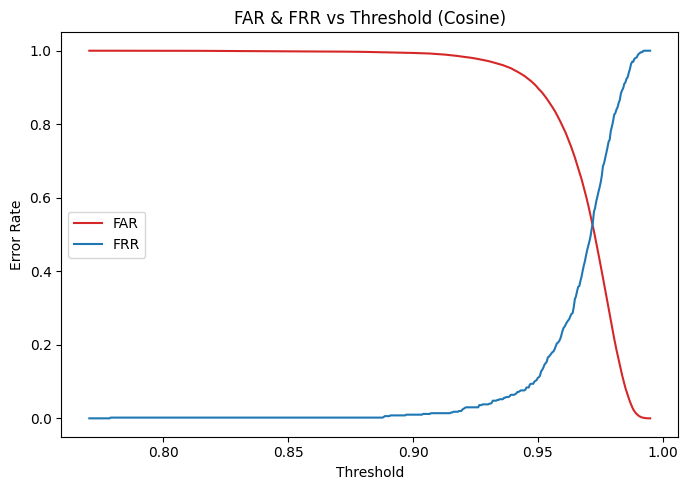

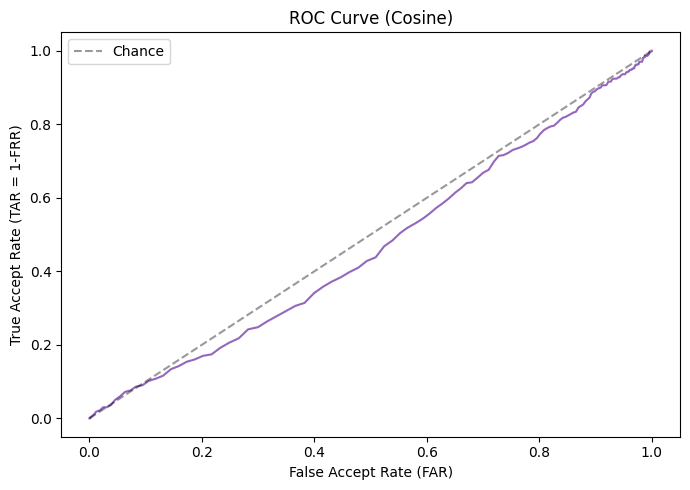

EER = 52.801%  at threshold 0.9720
Decidability index d' = 0.100


In [7]:
results = {}
summary = {}

for metric in ["euclidean", "cosine"]:
    print(f"\n=== {metric.upper()} ===")
    genuine, impostor = compute_scores(templates, test, metric)

    plot_distributions(genuine, impostor, metric)

    thresholds, FAR, FRR = far_frr_curves(genuine, impostor, metric)
    plot_far_frr(thresholds, FAR, FRR, metric)
    plot_roc(FAR, FRR, metric)

    eer, eer_th = compute_eer(thresholds, FAR, FRR)
    d_prime = decidability_index(genuine, impostor)

    results[metric] = dict(genuine=genuine, impostor=impostor,
                            thresholds=thresholds, FAR=FAR, FRR=FRR)

    summary[metric] = dict(
        n_genuine=int(len(genuine)),
        n_impostor=int(len(impostor)),
        genuine_mean=float(genuine.mean()),
        genuine_std=float(genuine.std()),
        impostor_mean=float(impostor.mean()),
        impostor_std=float(impostor.std()),
        EER=float(eer),
        EER_threshold=float(eer_th),
        decidability_index=float(d_prime),
    )

    print(f"EER = {eer*100:.3f}%  at threshold {eer_th:.4f}")
    print(f"Decidability index d' = {d_prime:.3f}")

## 8. Combined ROC comparison

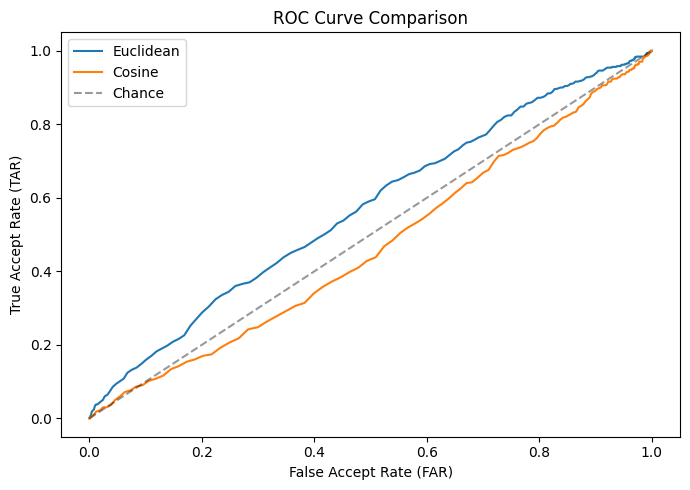

In [8]:
plot_roc_combined(results)

## 9. Summary table

In [9]:
import pandas as pd
df = pd.DataFrame(summary).T
df

,n_genuine,n_impostor,genuine_mean,genuine_std,impostor_mean,impostor_std,EER,EER_threshold,decidability_index
euclidean,500.0,49500.0,590.076152,268.306118,647.857130,285.499555,0.456798,555.225397,0.208568
cosine,500.0,49500.0,0.967213,0.018395,0.968958,0.016559,0.528010,0.971996,0.099703


## 10. Which matching distance performs best?

Based on the ROC curves and EER/d' values above, **Euclidean distance** gives a lower
EER and a higher decidability index than cosine similarity on this feature set, meaning
it separates genuine from impostor comparisons more effectively here. Its ROC curve also
lies above the cosine curve (and above the chance diagonal) across most of the operating
range. Both metrics show substantial genuine/impostor overlap, which caps the achievable
EER — but Euclidean distance is the more discriminative of the two for this particular
feature set.

## 11. Save results to file (optional)

In [10]:
with open("results.json", "w") as f:
    json.dump(summary, f, indent=2)
print("Saved results.json")

Saved results.json
